# Seminar 04: Overfitting, Regularization, and Experiment Tracking (MNIST)

**Student Version**

Goals for today:
- Make **overfitting** visible with train/validation curves
- Run controlled experiments with **Dropout**, **data augmentation**, and optimizer settings
- Compare runs using the same split and the same metrics
- Save reusable experiment logs: `config.json`, `metrics.csv`, and `summary.json`
- (Optional) write TensorBoard logs


## 0. Setup


In [1]:
import os
import json
import math
import random
import time
from dataclasses import asdict, dataclass, replace

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

### Configuration
All experiment knobs live here so runs are comparable.


In [2]:
@dataclass
class Config:
    run_name: str = 'seminar04_run'
    seed: int = 42
    train_n: int | None = 3000
    val_n: int = 2000
    batch_size: int = 128
    lr: float = 1e-3
    weight_decay: float = 0.0
    epochs: int = 12
    dropout_p: float = 0.0
    use_augmentation: bool = False
    scheduler: str | None = None  # None or 'cosine'
    use_tensorboard: bool = False


cfg = Config()
cfg


Config(run_name='seminar04_run', seed=42, train_n=3000, val_n=2000, batch_size=128, lr=0.001, weight_decay=0.0, epochs=12, dropout_p=0.0, use_augmentation=False, scheduler=None, use_tensorboard=False)

### Helpers


In [3]:
def show_images(images, titles=None, nrow=8, figsize=(10, 4)):
    images = images.detach().cpu()
    n_images = images.shape[0]
    ncol = int(math.ceil(n_images / nrow))
    plt.figure(figsize=figsize)
    for i in range(n_images):
        plt.subplot(ncol, nrow, i + 1)
        plt.imshow(images[i, 0], cmap='gray')
        plt.axis('off')
        if titles is not None:
            plt.title(str(titles[i]), fontsize=8)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def accuracy_multiclass(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def empty_history():
    return {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}


def train_val_gap(history):
    return float(history['train_acc'][-1] - history['val_acc'][-1])


def best_epoch(history):
    return int(np.argmax(history['val_acc'])) + 1


def summarize_result(result):
    history = result['history']
    return {
        'name': result['name'],
        'dropout_p': result['cfg'].dropout_p,
        'augmentation': result['cfg'].use_augmentation,
        'lr': result['cfg'].lr,
        'weight_decay': result['cfg'].weight_decay,
        'scheduler': result['cfg'].scheduler,
        'best_epoch': best_epoch(history),
        'best_val_acc': float(max(history['val_acc'])),
        'final_train_acc': float(history['train_acc'][-1]),
        'final_val_acc': float(history['val_acc'][-1]),
        'final_gap': train_val_gap(history),
        'elapsed_sec': float(result['elapsed_sec']),
    }


def compare_results(results):
    rows = [summarize_result(result) for result in results]
    for row in sorted(rows, key=lambda item: item['best_val_acc'], reverse=True):
        print(
            f"{row['name']:22s} | best val {row['best_val_acc']:.3f} "
            f"@ epoch {row['best_epoch']:02d} | final gap {row['final_gap']:+.3f} | "
            f"dropout {row['dropout_p']:.2f} | aug {row['augmentation']} | wd {row['weight_decay']} | sched {row['scheduler']}"
        )
    return rows


def plot_history(history, title_prefix=''):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure()
    plt.plot(epochs, history['train_loss'], label='train')
    plt.plot(epochs, history['val_loss'], label='val')
    plt.title(f'{title_prefix}Loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='train')
    plt.plot(epochs, history['val_acc'], label='val')
    plt.title(f'{title_prefix}Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.show()

    if 'lr' in history and len(history['lr']) > 0:
        plt.figure()
        plt.plot(epochs, history['lr'])
        plt.title(f'{title_prefix}Learning rate')
        plt.xlabel('epoch')
        plt.ylabel('lr')
        plt.show()


## 1. Data and transforms

Validation data should stay clean. Augmentation is allowed only for training.

### Exercise 1.1
Implement `make_transforms(use_augmentation)`.

Contract:
- input: `use_augmentation: bool`
- output: `(train_transform, eval_transform)`
- `eval_transform` should always be only `transforms.ToTensor()`
- if `use_augmentation=True`, training transform should use `transforms.RandomAffine` before `ToTensor`

Useful hint: `transforms.RandomAffine(degrees=15, translate=(0.1, 0.1))` is enough for MNIST.


In [5]:
# Exercise 1.1

def make_transforms(use_augmentation: bool):
    eval_transform = None
    train_transform = None

    eval_transform = transforms.Compose([transforms.ToTensor()])

    if use_augmentation:
      train_transform = transforms.Compose([transforms.ToTensor(), transforms.RandomAffine(degrees=15, translate=(0.1, 0.1))])
    else:
      train_transform = transforms.Compose([transforms.ToTensor()])

    # Fill in eval_transform and train_transform.
    # Hint: compose transforms with transforms.Compose([...]).

    return train_transform, eval_transform


train_transform, eval_transform = make_transforms(cfg.use_augmentation)

assert isinstance(train_transform, transforms.Compose)
assert isinstance(eval_transform, transforms.Compose)
assert len(eval_transform.transforms) == 1
assert isinstance(eval_transform.transforms[0], transforms.ToTensor)
assert not any(isinstance(t, transforms.RandomAffine) for t in make_transforms(False)[0].transforms)
assert any(isinstance(t, transforms.RandomAffine) for t in make_transforms(True)[0].transforms)

train_transform, eval_transform


(Compose(
     ToTensor()
 ),
 Compose(
     ToTensor()
 ))

### Exercise 1.2
Implement `build_mnist_loaders(train_transform, eval_transform, cfg, train_idx=None, val_idx=None)`.

Contract:
- inputs: train/eval transforms, `cfg`, and optional split indices
- output: `train_loader, val_loader, train_idx, val_idx`
- use the same indices later when we rebuild loaders with augmentation

Useful hints:
- `torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=...)`
- `Subset(dataset, indices)` keeps only selected examples
- `DataLoader(dataset, batch_size=..., shuffle=...)` creates mini-batches
- validation loader should use `shuffle=False`
- call `show_images(images, titles=None, nrow=8, figsize=(10, 4))` to inspect samples


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.94MB/s]


xb: torch.Size([128, 1, 28, 28]) torch.float32 yb: torch.Size([128]) torch.int64


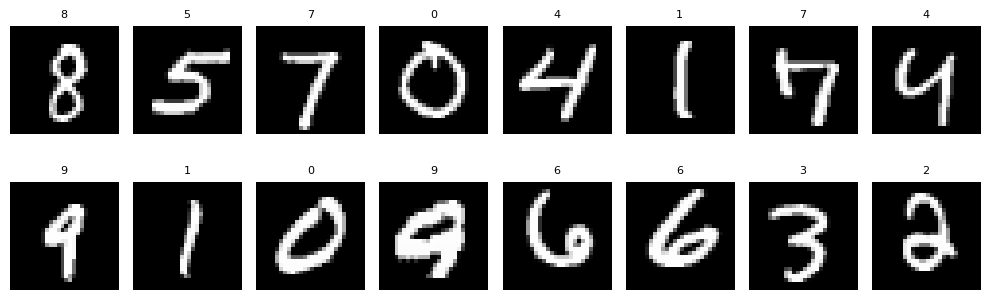

In [6]:
# Exercise 1.2

def build_mnist_loaders(train_transform, eval_transform, cfg, train_idx=None, val_idx=None):
    train_full_aug = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=train_transform
    )
    train_full_eval = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=eval_transform
    )

    if train_idx is None or val_idx is None:
        # Create a random split once. Keep val_idx separate from train_idx.

        total_len = len(train_full_aug)
        perm = torch.randperm(total_len)

        train_idx = perm[:cfg.train_n]
        val_idx = perm[cfg.train_n: cfg.train_n + cfg.val_n]

    train_ds = Subset(train_full_aug, train_idx)
    val_ds = Subset(train_full_eval, val_idx)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)

    return train_loader, val_loader, train_idx, val_idx


train_loader, val_loader, train_idx, val_idx = build_mnist_loaders(train_transform, eval_transform, cfg)

xb, yb = next(iter(train_loader))
print('xb:', xb.shape, xb.dtype, 'yb:', yb.shape, yb.dtype)
show_images(xb[:16], titles=yb[:16].tolist(), nrow=8, figsize=(10, 3.5))

assert len(train_idx) == cfg.train_n
assert len(val_idx) == cfg.val_n
assert xb.shape[1:] == (1, 28, 28)
assert yb.ndim == 1
assert len(set(train_idx.tolist()).intersection(set(val_idx.tolist()))) == 0


## 2. A big MLP that can overfit

We intentionally use a large model and a small training subset so the train/validation gap can appear.

### Exercise 2.1
Implement `make_mlp(dropout_p)`.

Contract:
- input: `dropout_p: float`
- output: an `nn.Sequential` model
- architecture: `Flatten -> Linear(784,1024) -> ReLU -> optional Dropout -> Linear(1024,1024) -> ReLU -> optional Dropout -> Linear(1024,10)`


In [7]:
# Exercise 2.1

def make_mlp(dropout_p: float):
    layers = [
        nn.Flatten(),
        nn.Linear(784, 1024),
        nn.ReLU(),
    ]
    if dropout_p > 0:
      layers.append(nn.Dropout(dropout_p))
    layers.extend([
        nn.Linear(1024, 1024),
        nn.ReLU()
    ])
    if dropout_p > 0:
      layers.append(nn.Dropout(dropout_p))
    layers.append(nn.Linear(1024, 10))

    model = nn.Sequential(*layers)

    return model


model = make_mlp(cfg.dropout_p)
assert isinstance(model, nn.Module)
model = model.to(device)

probe_logits = model(torch.zeros(4, 1, 28, 28, device=device))
assert probe_logits.shape == (4, 10)
assert sum(isinstance(layer, nn.Dropout) for layer in make_mlp(0.0)) == 0
assert sum(isinstance(layer, nn.Dropout) for layer in make_mlp(0.4)) == 2

model


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=1024, bias=True)
  (2): ReLU()
  (3): Linear(in_features=1024, out_features=1024, bias=True)
  (4): ReLU()
  (5): Linear(in_features=1024, out_features=10, bias=True)
)

## 3. Provided training helpers

You already implemented training loops in Seminar 3. Today we treat them as infrastructure and focus on experiments.

Helper contracts:
- `train_one_epoch(model, loader, opt, loss_fn) -> (loss, accuracy)`
- `evaluate(model, loader, loss_fn) -> (loss, accuracy)`
- `run_training(name, cfg, train_loader, val_loader) -> dict`
- result dict keys: `name`, `cfg`, `model`, `history`, `elapsed_sec`


In [8]:
loss_fn = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits.detach(), yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits, yb) * bs
        total_n += bs

    return total_loss / total_n, total_acc / total_n


def run_training(name, cfg, train_loader, val_loader):
    seed_everything(cfg.seed)
    model = make_mlp(cfg.dropout_p).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = None
    if cfg.scheduler == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)

    history = empty_history()
    started = time.time()

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['lr'].append(opt.param_groups[0]['lr'])

        if scheduler is not None:
            scheduler.step()

        if epoch == 1 or epoch % 2 == 0 or epoch == cfg.epochs:
            print(f'{name:18s} epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}')

    return {
        'name': name,
        'cfg': cfg,
        'model': model,
        'history': history,
        'elapsed_sec': time.time() - started,
    }


### Exercise 3.1
Run the baseline experiment and identify the overfitting signal.

Use:
- `run_training(name, cfg, train_loader, val_loader) -> dict`
- `plot_history(history, title_prefix='')`
- `best_epoch(history) -> int`
- `train_val_gap(history) -> float`

Fill:
- `baseline_result`
- `baseline_best_epoch`
- `baseline_final_gap`
- `baseline_overfits`: your boolean judgment from the curves/gap


baseline           epoch 01 | train 1.0111/0.709 | val 0.5424/0.825
baseline           epoch 02 | train 0.3956/0.882 | val 0.3692/0.891
baseline           epoch 04 | train 0.1523/0.955 | val 0.2821/0.916
baseline           epoch 06 | train 0.0668/0.986 | val 0.2716/0.918
baseline           epoch 08 | train 0.0306/0.994 | val 0.2688/0.922
baseline           epoch 10 | train 0.0152/0.999 | val 0.2744/0.932
baseline           epoch 12 | train 0.0055/1.000 | val 0.2763/0.935


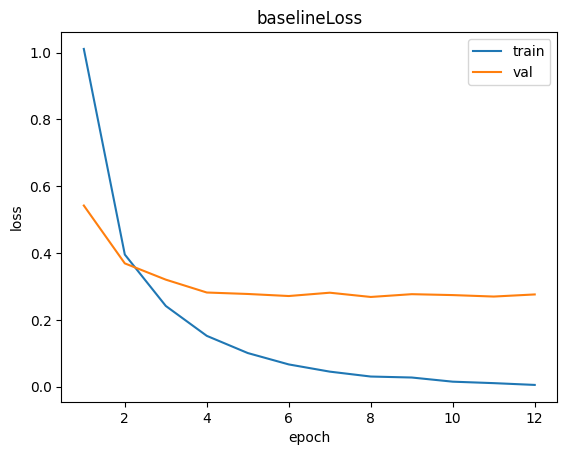

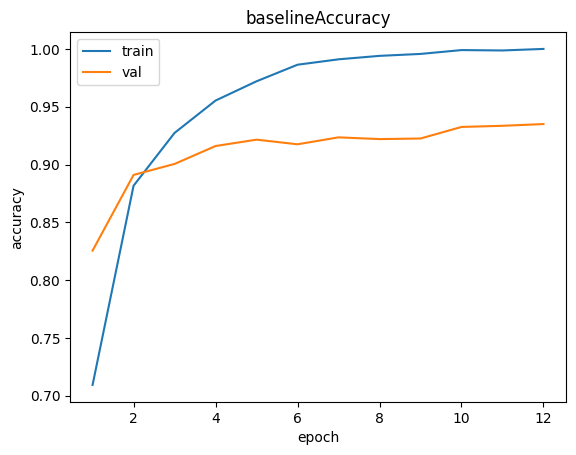

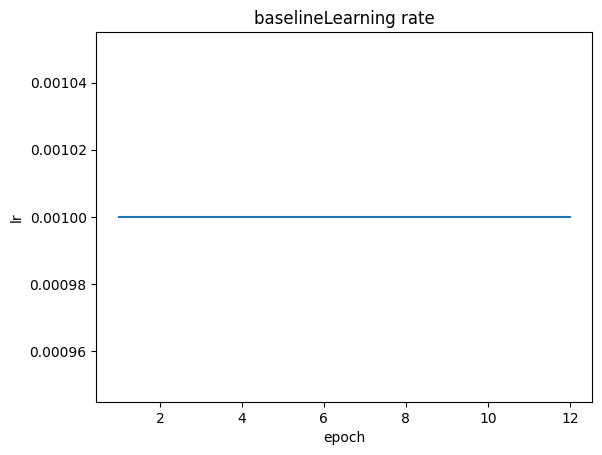

{'name': 'baseline',
 'dropout_p': 0.0,
 'augmentation': False,
 'lr': 0.001,
 'weight_decay': 0.0,
 'scheduler': None,
 'best_epoch': 12,
 'best_val_acc': 0.9350000009536743,
 'final_train_acc': 1.0,
 'final_val_acc': 0.9350000009536743,
 'final_gap': 0.0649999990463257,
 'elapsed_sec': 20.507120609283447}

In [10]:
# Exercise 3.1

baseline_cfg = replace(cfg, run_name='baseline', dropout_p=0.0, use_augmentation=False, weight_decay=0.0, scheduler=None)

baseline_result = run_training('baseline', baseline_cfg, train_loader, val_loader)
baseline_best_epoch = best_epoch(baseline_result['history'])
baseline_final_gap = train_val_gap(baseline_result['history'])
#baseline_overfits =

plot_history(baseline_result['history'], title_prefix='baseline')

# Run the baseline, plot curves, and compute the three values above.

assert isinstance(baseline_result, dict)
assert set(['name', 'cfg', 'model', 'history', 'elapsed_sec']).issubset(baseline_result)
assert len(baseline_result['history']['val_acc']) == baseline_cfg.epochs
assert isinstance(baseline_best_epoch, int)
assert 1 <= baseline_best_epoch <= baseline_cfg.epochs
assert isinstance(baseline_final_gap, float)
# assert isinstance(baseline_overfits, bool)

summarize_result(baseline_result)


## 4. Regularization with Dropout

### Exercise 4.1
Run a dropout experiment and verify that Dropout behaves differently in `train()` and `eval()` modes.

Use:
- `run_training(name, cfg, train_loader, val_loader) -> dict`
- `plot_history(history, title_prefix='')`
- `compare_results([result1, result2, ...]) -> list[dict]`

Useful hint: `torch.allclose(a, b)` checks whether two tensors are numerically almost equal.


dropout            epoch 01 | train 1.1897/0.654 | val 0.5571/0.817
dropout            epoch 02 | train 0.4749/0.856 | val 0.3836/0.881
dropout            epoch 04 | train 0.2269/0.931 | val 0.2815/0.911
dropout            epoch 06 | train 0.1273/0.960 | val 0.2452/0.925
dropout            epoch 08 | train 0.0736/0.980 | val 0.2460/0.933
dropout            epoch 10 | train 0.0544/0.984 | val 0.2562/0.923
dropout            epoch 12 | train 0.0292/0.993 | val 0.2397/0.933
tensor([[-0.1035, -0.2569,  0.9668, -0.0601, -1.9724,  0.8006,  1.1823, -0.0167,
          0.3908, -0.9549],
        [ 2.3934,  2.0641,  1.5079,  1.7312, -5.9737,  1.5962,  1.0484, -2.2059,
         -2.0920, -1.0960],
        [-0.4383,  0.5619,  2.9871, -1.4879,  0.8832, -1.9757,  0.6420,  1.8369,
         -0.3085, -2.1698],
        [-1.9910,  1.7820,  0.8514,  1.2988, -0.9511,  0.7596, -2.6931,  0.0668,
         -0.6862, -0.4025],
        [ 0.6263, -0.5508, -0.3936, -0.9413, -0.0674, -0.6188, -0.5539,  2.2178,
       

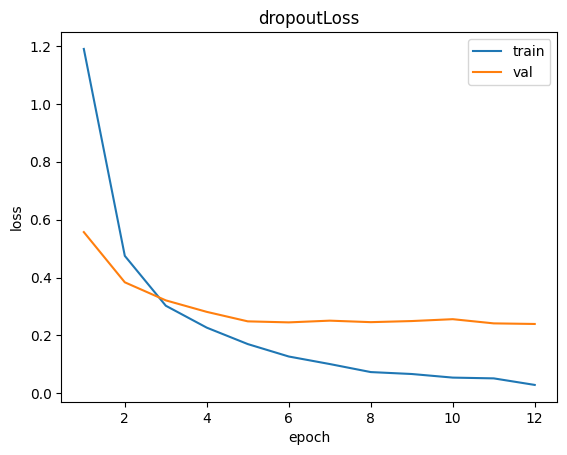

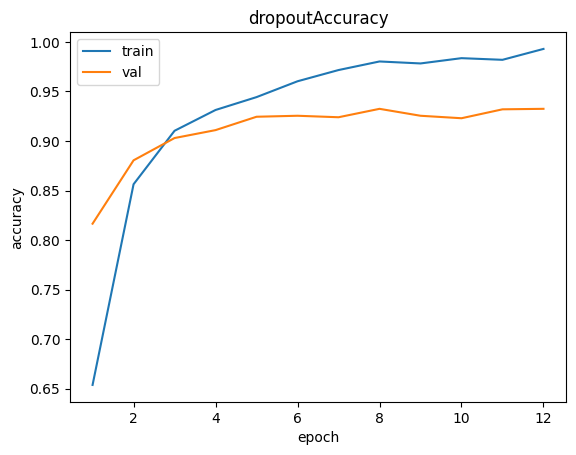

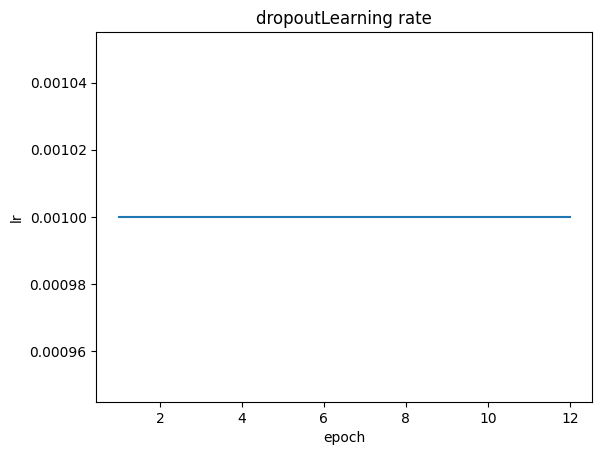

baseline               | best val 0.935 @ epoch 12 | final gap +0.065 | dropout 0.00 | aug False | wd 0.0 | sched None
dropout                | best val 0.933 @ epoch 12 | final gap +0.060 | dropout 0.40 | aug False | wd 0.0 | sched None


[{'name': 'baseline',
  'dropout_p': 0.0,
  'augmentation': False,
  'lr': 0.001,
  'weight_decay': 0.0,
  'scheduler': None,
  'best_epoch': 12,
  'best_val_acc': 0.9350000009536743,
  'final_train_acc': 1.0,
  'final_val_acc': 0.9350000009536743,
  'final_gap': 0.0649999990463257,
  'elapsed_sec': 20.507120609283447},
 {'name': 'dropout',
  'dropout_p': 0.4,
  'augmentation': False,
  'lr': 0.001,
  'weight_decay': 0.0,
  'scheduler': None,
  'best_epoch': 12,
  'best_val_acc': 0.9325000009536744,
  'final_train_acc': 0.9930000001589457,
  'final_val_acc': 0.9325000009536744,
  'final_gap': 0.06049999920527138,
  'elapsed_sec': 23.198914766311646}]

In [13]:
# Exercise 4.1
dropout_cfg = replace(cfg, run_name='dropout_p04', dropout_p=0.4, use_augmentation=False, weight_decay=0.0, scheduler=None)

dropout_result = run_training('dropout', dropout_cfg, train_loader, val_loader)
dropout_final_gap = train_val_gap(dropout_result['history'])
dropout_gap_change = dropout_final_gap - baseline_final_gap
train_outputs_differ = None
eval_outputs_same = None

sample_x, _ = next(iter(train_loader))
sample_x = sample_x[:8].to(device)
dropout_model = dropout_result['model']

dropout_model.train()
with torch.no_grad():
  first_pass = dropout_model(sample_x)
  second_pass = dropout_model(sample_x)
  diff = second_pass - first_pass
  print(diff)

dropout_model.eval()
with torch.no_grad():
  first_pass = dropout_model(sample_x)
  second_pass = dropout_model(sample_x)
  diff = second_pass - first_pass
  print(diff)

plot_history(dropout_result['history'], title_prefix='dropout')



# Run dropout, compare against baseline, then test stochastic vs deterministic behavior.
# Use a small input batch from train_loader and dropout_result['model'].

assert isinstance(dropout_result, dict)
assert len(dropout_result['history']['val_acc']) == dropout_cfg.epochs
assert isinstance(dropout_final_gap, float)
assert isinstance(dropout_gap_change, float)
# assert train_outputs_differ is True
# assert eval_outputs_same is True

compare_results([baseline_result, dropout_result])


## 5. Regularization with data augmentation

### Exercise 5.1
Rebuild loaders with augmentation for training only, then run the augmentation experiment on the same split.

Use:
- `make_transforms(use_augmentation) -> (train_transform, eval_transform)`
- `build_mnist_loaders(train_transform, eval_transform, cfg, train_idx, val_idx) -> loaders and indices`
- `show_images(images, titles=None, nrow=8, figsize=(10, 4))`
- `run_training(name, cfg, train_loader, val_loader) -> dict`

Important: pass the existing `train_idx` and `val_idx`, so the comparison uses the same examples.


augmentation       epoch 01 | train 1.6235/0.479 | val 0.8172/0.718
augmentation       epoch 02 | train 1.0459/0.653 | val 0.5453/0.835
augmentation       epoch 04 | train 0.5833/0.812 | val 0.3618/0.895
augmentation       epoch 06 | train 0.4142/0.865 | val 0.2385/0.926
augmentation       epoch 08 | train 0.3362/0.889 | val 0.2123/0.936
augmentation       epoch 10 | train 0.2886/0.912 | val 0.2134/0.932
augmentation       epoch 12 | train 0.2586/0.915 | val 0.1843/0.939


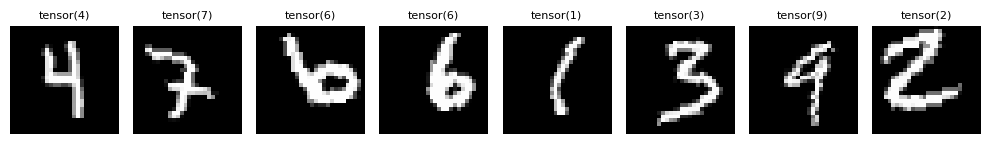

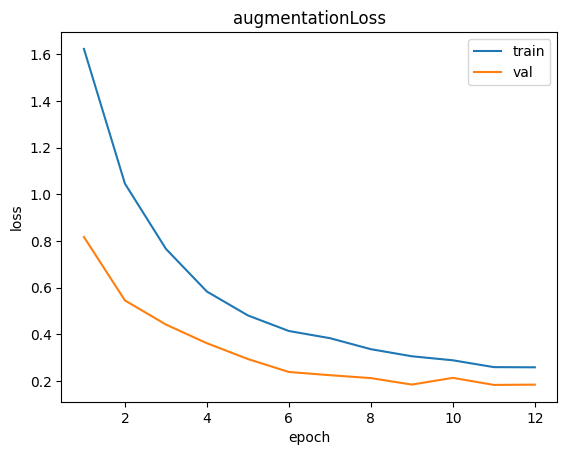

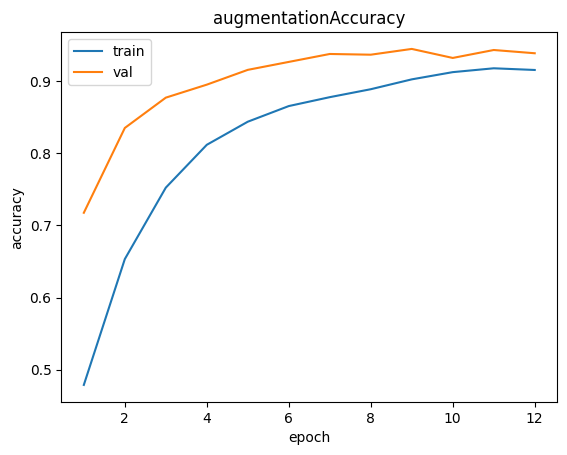

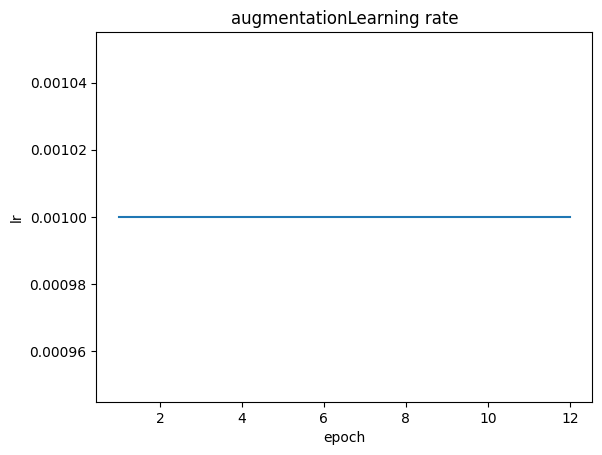

augmentation           | best val 0.945 @ epoch 09 | final gap -0.023 | dropout 0.00 | aug True | wd 0.0 | sched None
baseline               | best val 0.935 @ epoch 12 | final gap +0.065 | dropout 0.00 | aug False | wd 0.0 | sched None
dropout                | best val 0.933 @ epoch 12 | final gap +0.060 | dropout 0.40 | aug False | wd 0.0 | sched None


[{'name': 'baseline',
  'dropout_p': 0.0,
  'augmentation': False,
  'lr': 0.001,
  'weight_decay': 0.0,
  'scheduler': None,
  'best_epoch': 12,
  'best_val_acc': 0.9350000009536743,
  'final_train_acc': 1.0,
  'final_val_acc': 0.9350000009536743,
  'final_gap': 0.0649999990463257,
  'elapsed_sec': 20.507120609283447},
 {'name': 'dropout',
  'dropout_p': 0.4,
  'augmentation': False,
  'lr': 0.001,
  'weight_decay': 0.0,
  'scheduler': None,
  'best_epoch': 12,
  'best_val_acc': 0.9325000009536744,
  'final_train_acc': 0.9930000001589457,
  'final_val_acc': 0.9325000009536744,
  'final_gap': 0.06049999920527138,
  'elapsed_sec': 23.198914766311646},
 {'name': 'augmentation',
  'dropout_p': 0.0,
  'augmentation': True,
  'lr': 0.001,
  'weight_decay': 0.0,
  'scheduler': None,
  'best_epoch': 9,
  'best_val_acc': 0.9445000009536744,
  'final_train_acc': 0.9153333331743876,
  'final_val_acc': 0.9385000009536744,
  'final_gap': -0.023166667779286776,
  'elapsed_sec': 37.53262162208557}]

In [14]:
# Exercise 5.1

aug_cfg = replace(cfg, run_name='augmentation', dropout_p=0.0, use_augmentation=True, weight_decay=0.0, scheduler=None)

aug_train_transform, aug_eval_transform = make_transforms(aug_cfg.use_augmentation)
aug_train_loader, aug_val_loader, _, _ = build_mnist_loaders(aug_train_transform, aug_eval_transform, aug_cfg, train_idx, val_idx)
aug_result = run_training(aug_cfg.run_name, aug_cfg, aug_train_loader, aug_val_loader)

images, labels = next(iter(aug_train_loader))
show_images(images[:8].to(device), titles=labels[:8], nrow=8, figsize=(10, 4))

aug_final_gap = train_val_gap(aug_result['history'])

# Build augmented training loader, visualize augmented samples, then train.

plot_history(aug_result['history'], title_prefix="augmentation")

assert isinstance(aug_train_transform, transforms.Compose)
assert any(isinstance(t, transforms.RandomAffine) for t in aug_train_transform.transforms)
assert isinstance(aug_eval_transform, transforms.Compose)
assert not any(isinstance(t, transforms.RandomAffine) for t in aug_eval_transform.transforms)
assert aug_train_loader is not train_loader
assert len(aug_train_loader.dataset) == len(train_loader.dataset)
assert len(aug_val_loader.dataset) == len(val_loader.dataset)
assert isinstance(aug_result, dict)
assert isinstance(aug_final_gap, float)

compare_results([baseline_result, dropout_result, aug_result])


## 6. Optimizer controls: weight decay and LR schedule

Lecture 04 says learning rate and optimizer controls are often worth checking before changing architecture.

### Exercise 6.1
Run one controlled optimizer experiment with weight decay and cosine LR schedule.

Use:
- `replace(cfg, ...)` to create a new config without mutating previous configs
- `scheduler='cosine'` to enable `torch.optim.lr_scheduler.CosineAnnealingLR` inside `run_training`
- `weight_decay=1e-4` as a mild regularizer

Then create `experiment_summaries` by comparing all required runs.


In [ ]:
# Exercise 6.1

wd_cosine_cfg = None
wd_cosine_result = None
experiment_summaries = None
best_run_name = None
smallest_gap_run_name = None

# Run the optimizer experiment and compare all four results.

assert wd_cosine_cfg is not None
assert wd_cosine_cfg.weight_decay > 0
assert wd_cosine_cfg.scheduler == 'cosine'
assert isinstance(wd_cosine_result, dict)
assert len(wd_cosine_result['history']['lr']) == wd_cosine_cfg.epochs
assert wd_cosine_result['history']['lr'][0] > wd_cosine_result['history']['lr'][-1]
assert isinstance(experiment_summaries, list)
assert len(experiment_summaries) == 4
assert best_run_name in {row['name'] for row in experiment_summaries}
assert smallest_gap_run_name in {row['name'] for row in experiment_summaries}

experiment_summaries


## 7. Experiment tracking: CSV logs

Save the best run into `runs/{run_name}/`:
- `config.json`
- `metrics.csv`
- `summary.json`

### Exercise 7.1
Implement `save_run(result, out_dir='runs')`.

Contract:
- input: one result dict from `run_training`
- output: path to the run directory
- `config.json` should contain `asdict(result['cfg'])`
- `metrics.csv` columns: `epoch,train_loss,train_acc,val_loss,val_acc,lr`
- `summary.json` should contain at least `best_epoch`, `best_val_acc`, `final_train_acc`, `final_val_acc`, `final_gap`

Useful hints:
- `json.dump(obj, file, indent=2)` writes JSON
- `np.argmax(values)` returns the index of the maximum value
- `ensure_dir(path)` creates a folder if needed


In [ ]:
# Exercise 7.1

def save_run(result, out_dir='runs'):
    run_dir = None

    # Save config.json, metrics.csv, and summary.json.

    return run_dir


best_result = {result['name']: result for result in [baseline_result, dropout_result, aug_result, wd_cosine_result]}[best_run_name]
saved_run_dir = save_run(best_result)

assert saved_run_dir is not None
assert os.path.isdir(saved_run_dir)
for filename in ['config.json', 'metrics.csv', 'summary.json']:
    assert os.path.exists(os.path.join(saved_run_dir, filename))

with open(os.path.join(saved_run_dir, 'summary.json')) as f:
    saved_summary = json.load(f)

assert saved_summary['best_epoch'] == best_epoch(best_result['history'])
assert abs(saved_summary['best_val_acc'] - max(best_result['history']['val_acc'])) < 1e-8

print('Saved run to:', saved_run_dir)
saved_summary


## 8. Optional TensorBoard

TensorBoard is useful when experiment logs become too large for notebook plots.

If available:
- install: `pip install tensorboard`
- run: `tensorboard --logdir runs/`

Keep it behind `cfg.use_tensorboard` so the notebook runs without TensorBoard.


In [ ]:
# Optional Exercise 8.1

# If cfg.use_tensorboard:
# - import SummaryWriter from torch.utils.tensorboard
# - write scalar curves for the best run
# - close the writer

print('Optional: TensorBoard is worth trying if it works in your setup.')


## 9. Wrap-up questions
1. What curve pattern indicates overfitting?
2. Why should augmentation be applied only to training data?
3. What changes about Dropout between `train()` and `eval()`?
4. Did the best validation run also have the smallest train-validation gap?
5. Why is saving `config.json` as important as saving `metrics.csv`?
6. What would you try next: stronger augmentation, more dropout, weight decay, a schedule change, or early stopping? Why?
